In [ ]:
import os
from pathlib import Path

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))  # go to ~/crossdem/ by jumping up twice
OUT_DIR = os.path.join(BASE_DIR, "datasets")

os.makedirs(OUT_DIR, exist_ok=True)

with open(os.path.join(OUT_DIR, "output.txt"), "w") as f:
    f.write("hello world")

print(f"Written to {OUT_DIR}/output.txt")

Written to /home/mhetac/Documents/GitHub/crossdem/datasets/output.txt


# Textual Analysis


In [31]:
import pandas
import glob

all_melonis = glob.glob(f"{BASE_DIR}/datasets/meloni/csv_out/*.csv")
meloni_df =  pandas.concat([pandas.read_csv(f, nrows=1) for f in all_melonis], ignore_index=True)

degasperi_df = pandas.read_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_speeches.csv")

meloni_df.head()

,politician,historical_date,location,tags,description,title,url,audio_file,text
0,meloni,2026-05-21,NISCEMI,[],"Il Presidente del Consiglio, Giorgia Meloni, s...",Punto stampa del Presidente Giorgia Meloni a N...,https://youtu.be/iOFR7Ae9cHU?si=0jxlIq30L1GWEz6v,crossdem/datasets/meloni/audio_out/WEz6v_audio...,Diciamo cosa è venuto fuori da questa riunione...
1,meloni,2026-05-08,MILANO,[],"Il Presidente del Consiglio, Giorgia Meloni, h...",Punto stampa del Presidente Giorgia Meloni pri...,https://youtu.be/i4Dyv8CQ7VA?si=dmvMAn8kQ7L65bjC,crossdem/datasets/meloni/audio_out/65bjC_audio...,"Mi pare un incontro molto ampio, molto costrut..."
2,meloni,2026-05-08,MILANO,[],"Il Presidente del Consiglio, Giorgia Meloni, h...",Il Presidente Giorgia Meloni interviene a “L’A...,https://youtu.be/F4-PR5iJv0E?si=xOoatF-_4Kz6rOAc,crossdem/datasets/meloni/audio_out/6rOAc_audio...,"Buon pomeriggio a tutti, grazie per l'invito, ..."
3,meloni,2026-05-07,NaN,[],#agricoltori #cia #giorgiameloni #governomeloni,L'intervento di Giorgia Meloni in occasione de...,https://youtu.be/A_pHRztwshY?si=g12j2iNOGap5gm3A,crossdem/datasets/meloni/audio_out/5gm3A_audio...,L'Italia è a tutti gli effetti una super poten...
4,meloni,2026-05-06,REGIONE AUTONOMA FRIULI - VENEZIA GIULIA - CON...,[],Il mio intervento alla seduta straordinaria de...,L'intervento di Giorgia Meloni per il 50° anni...,https://youtu.be/RL-q9N7EtQE?si=gnA73YDdUye1GqzU,crossdem/datasets/meloni/audio_out/1GqzU_audio...,"Presidente della Repubblica, Distinte Autorità..."


In [26]:
degasperi_df.head()

,politician,historical_date,location,keywords,text
0,degasperi,1906-02-13,Trento,"['conseguenze del suffragio universale', 'part...",[...] La modalità del suffragio universale Qua...
1,degasperi,1902-01-2,Trento,"['questione universitaria', 'università italia...",[...] Incaricato dalla Presidenza dell’Associa...
2,degasperi,1906-05-15,Trento,"['suffragio universale', 'popoli', 'deputati',...",Introduzione Necessità di far politica Chi par...
3,degasperi,1906-09-10,Trento,"['applausi prolungati', 'studente carbonari', ...",[...] Parla il dott. Degasperi Entrando staman...
4,degasperi,1906-12-10,Trento,"['clericali', 'liberale', 'don rodrigo', 'clas...",La classificazione dei partiti riesce oltremod...



## Number of tokens per PM
> Measures the amount of collected data


In [29]:
import spacy

# Load Italian model if your speeches are in Italian, otherwise use en_core_web_sm
# pip install spacy && python3 -m spacy download it_core_news_sm
nlp = spacy.load("it_core_news_sm")


In [32]:

# Disable unneeded pipeline components for speed — we only need tokenization
nlp.select_pipes(enable=[])  # disables everything except tokenizer

def count_tokens(text):
    if pandas.isna(text) or not isinstance(text, str):
        return 0
    return len(nlp(text))

# Normalize column names so both DFs have 'text'
meloni_df["token_count"] = meloni_df["text"].apply(count_tokens)
degasperi_df["token_count"] = degasperi_df["text"].apply(count_tokens)

# Combine
combined_df = pandas.concat(
    [meloni_df[["politician", "token_count"]], degasperi_df[["politician", "token_count"]]],
    ignore_index=True
)

# Aggregate
token_summary = (
    combined_df
    .groupby("politician")["token_count"]
    .agg(total_tokens="sum", speech_count="count", avg_tokens_per_speech="mean")
    .reset_index()
)

print(token_summary)

  politician  total_tokens  speech_count  avg_tokens_per_speech
0  degasperi        609142           473            1287.826638
1     meloni        120116            72            1668.277778



## MTLD Measure of Textual Lexical Diversity
> Measures lexical diversity

By sequentially evaluating the Type-Token Ratio (TTR) across segments, MTLD avoids the common problem of shorter texts artificially inflating lexical diversity 


In [ ]:
from lexicalrichness import LexicalRichness

def compute_mtld(text):
    lex = LexicalRichness(text)
    # Need at least a few tokens for a meaningful MTLD
    if lex.words < 10:
        return None
    return lex.mtld(threshold=0.72)

meloni_df["mtld"] = meloni_df["text"].apply(compute_mtld)
degasperi_df["mtld"] = degasperi_df["text"].apply(compute_mtld)

combined_df = pandas.concat(
    [meloni_df[["politician", "mtld"]], degasperi_df[["politician", "mtld"]]],
    ignore_index=True
)

mtld_summary = (
    combined_df
    .groupby("politician")["mtld"]
    .agg(
        avg_mtld="mean",
        median_mtld="median",
        speech_count="count"
    )
    .reset_index()
)

print(mtld_summary)
meloni_df.head()
#degasperi_df.head()

  politician    avg_mtld  median_mtld  speech_count
0  degasperi  141.829723   137.642465           473
1     meloni  106.745090   104.917560            72


,politician,historical_date,location,keywords,text,token_count,mtld
0,degasperi,1906-02-13,Trento,"['conseguenze del suffragio universale', 'part...",[...] La modalità del suffragio universale Qua...,1313,145.027312
1,degasperi,1902-01-2,Trento,"['questione universitaria', 'università italia...",[...] Incaricato dalla Presidenza dell’Associa...,3449,159.972801
2,degasperi,1906-05-15,Trento,"['suffragio universale', 'popoli', 'deputati',...",Introduzione Necessità di far politica Chi par...,2258,135.551367
3,degasperi,1906-09-10,Trento,"['applausi prolungati', 'studente carbonari', ...",[...] Parla il dott. Degasperi Entrando staman...,491,168.422781
4,degasperi,1906-12-10,Trento,"['clericali', 'liberale', 'don rodrigo', 'clas...",La classificazione dei partiti riesce oltremod...,1064,128.144265


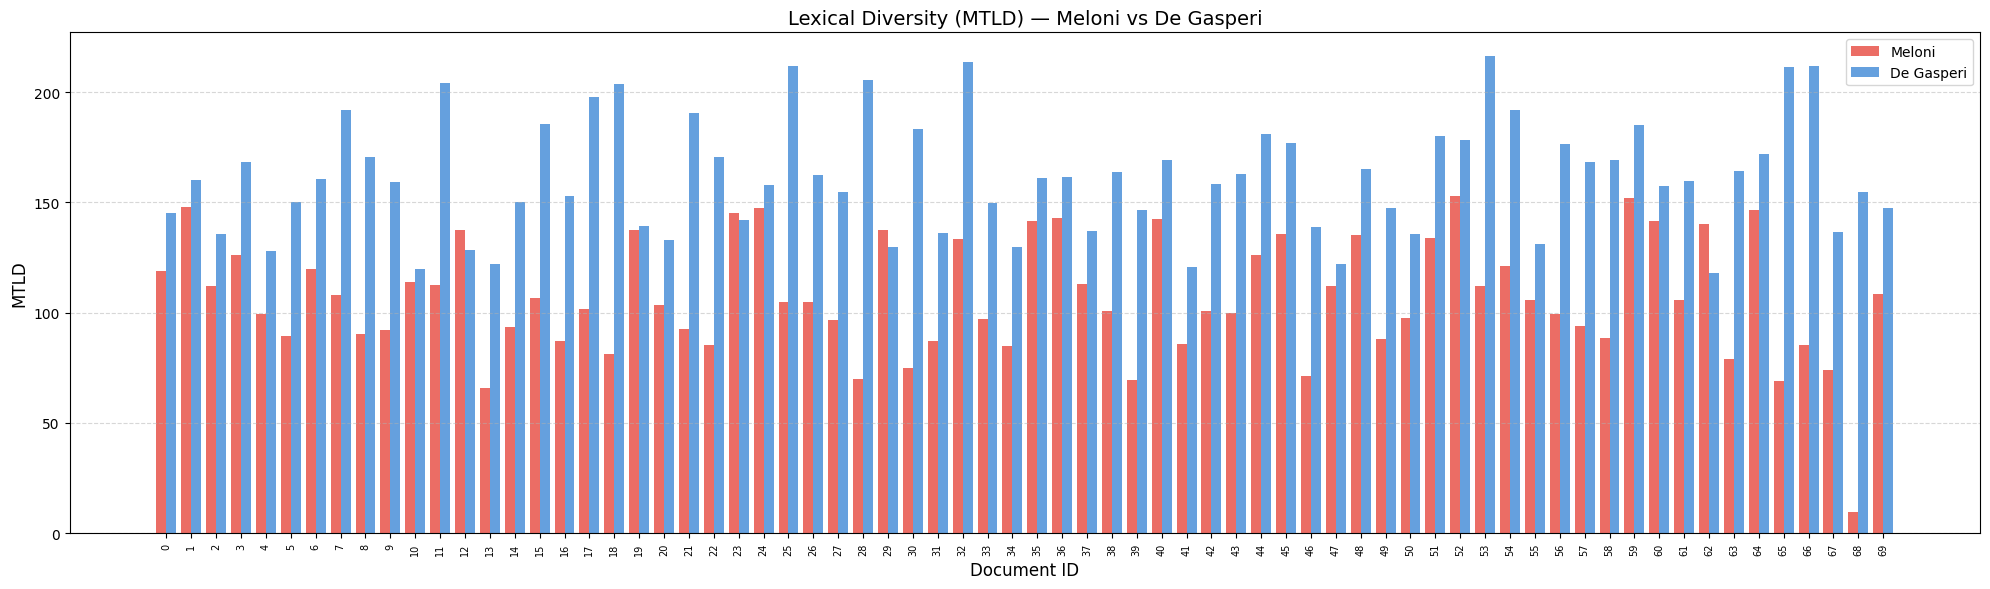

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Take first 70 docs from each
meloni_plot = meloni_df["mtld"].dropna().head(70).reset_index(drop=True)
degasperi_plot = degasperi_df["mtld"].dropna().head(70).reset_index(drop=True)

x = np.arange(70)
width = 0.4

fig, ax = plt.subplots(figsize=(20, 6))

ax.bar(x - width/2, meloni_plot, width, label="Meloni", color="#E8534A", alpha=0.85)
ax.bar(x + width/2, degasperi_plot, width, label="De Gasperi", color="#4A90D9", alpha=0.85)

ax.set_xlabel("Document ID", fontsize=12)
ax.set_ylabel("MTLD", fontsize=12)
ax.set_title("Lexical Diversity (MTLD) — Meloni vs De Gasperi", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(x, rotation=90, fontsize=7)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("mtld_comparison.png", dpi=150)
plt.show()


## Vocabulary Differences
> What are words that are used by De Gasperi and not by Meloni? And vice-versa

## Hapax legomena ratio
> Words that appear only once
> Can be a metric for vocabulary richness



## Sentiment Analysis

Oss: BERT cannot handle more than 512 tokens in one go
Oss: he raw probability scores and report distributions (e.g. median positive score per PM, per year) rather than hard positive/negative counts

### FEEL-IT: Emotion and Sentiment Classification for the Italian Language 

In [ ]:
from transformers import pipeline

# Binary sentiment: positive / negative
sentiment_classifier = pipeline(
    "text-classification",
    model="MilaNLProc/feel-it-italian-sentiment",
    top_k=2,
    device=0  # GPU; use -1 for CPU
)

# Emotion: joy / fear / anger / sadness
emotion_classifier = pipeline(
    "text-classification",
    model="MilaNLProc/feel-it-italian-emotion",
    top_k=2,
    device=0
)

In [ ]:
# sentiment classification
from transformers import pipeline
classifier = pipeline("text-classification",model='MilaNLProc/feel-it-italian-sentiment',top_k=2)
prediction = classifier("Oggi sono proprio contento!")
print(prediction)


ModuleNotFoundError: No module named 'transformers'

In [ ]:
# emotion classification
from transformers import pipeline
classifier = pipeline("text-classification",model='MilaNLProc/feel-it-italian-emotion',top_k=2)
prediction = classifier("Oggi sono proprio contento!")
print(prediction)

Citation:
@inproceedings{bianchi2021feel,
    title = {{"FEEL-IT: Emotion and Sentiment Classification for the Italian Language"}},
    author = "Bianchi, Federico and Nozza, Debora and Hovy, Dirk",
    booktitle = "Proceedings of the 11th Workshop on Computational Approaches to Subjectivity, Sentiment and Social Media Analysis",
    year = "2021",
    publisher = "Association for Computational Linguistics",
}


### Bert Multilingual Uncased

In [ ]:
# Using an automated pipeline
from transformers import pipeline

pipe = pipeline("text-classification", model="nlptown/bert-base-multilingual-uncased-sentiment")

In [ ]:
# Load the model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")
model = AutoModelForSequenceClassification.from_pretrained("nlptown/bert-base-multilingual-uncased-sentiment")


## Hate speech classification
